# 05a — E1 Cross-Dataset Evaluation on Celeb-DF v2

Evaluate the retrained E1 baseline CNN—trained only on FaceForensics++ full frames—on the fixed Celeb-DF v2 full-frame pilot without retraining, adaptation or threshold tuning.

This notebook reports both frame-level and video-level performance.


## 1. Run controls


In [1]:
INSTALL_DEPENDENCIES = False
RUN_EVALUATION = True
ALLOW_RESULT_OVERWRITE = False

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 32
NUM_WORKERS = 0

assert DECISION_THRESHOLD == 0.5
print("E1 Celeb-DF evaluation enabled:", RUN_EVALUATION)
print("Allow result overwrite:", ALLOW_RESULT_OVERWRITE)
print("Decision threshold:", DECISION_THRESHOLD)


E1 Celeb-DF evaluation enabled: True
Allow result overwrite: False
Decision threshold: 0.5


## 2. Environment and canonical paths


In [2]:
import json
import random
import subprocess
import sys
from pathlib import Path

if INSTALL_DEPENDENCIES:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision", "pandas", "matplotlib", "scikit-learn",
    ])

from google.colab import drive
drive.mount("/content/drive")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
PILOT_FRAMES_DIR = BASE_PATH / "celebdf_v2" / "pilot_frames"
MANIFEST_PATH = BASE_PATH / "celebdf_v2" / "celebdf_pilot_manifest.json"
CHECKPOINT_PATH = BASE_PATH / "saved_models" / "baseline_cnn.pth"
RESULTS_DIR = BASE_PATH / "results" / "cross_dataset"
PLOTS_DIR = BASE_PATH / "plots" / "cross_dataset"

RESULTS_JSON = RESULTS_DIR / "e1_celebdf_results.json"
FRAME_CSV = RESULTS_DIR / "e1_celebdf_frame_predictions.csv"
VIDEO_CSV = RESULTS_DIR / "e1_celebdf_video_predictions.csv"
FRAME_CM = PLOTS_DIR / "e1_celebdf_frame_confusion_matrix.png"
FRAME_ROC = PLOTS_DIR / "e1_celebdf_frame_roc_curve.png"
VIDEO_CM = PLOTS_DIR / "e1_celebdf_video_confusion_matrix.png"
VIDEO_ROC = PLOTS_DIR / "e1_celebdf_video_roc_curve.png"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for path, label in [
    (PILOT_FRAMES_DIR / "real", "Celeb-DF real frames"),
    (PILOT_FRAMES_DIR / "fake", "Celeb-DF fake frames"),
    (MANIFEST_PATH, "Celeb-DF pilot manifest"),
    (CHECKPOINT_PATH, "E1 checkpoint"),
]:
    if not path.exists(): raise FileNotFoundError(f"{label} not found: {path}")

if RUN_EVALUATION and not ALLOW_RESULT_OVERWRITE:
    existing=[p for p in [RESULTS_JSON,FRAME_CSV,VIDEO_CSV,FRAME_CM,FRAME_ROC,VIDEO_CM,VIDEO_ROC] if p.exists()]
    if existing:
        raise FileExistsError(
            "E1 external outputs already exist. Set ALLOW_RESULT_OVERWRITE = True only "
            f"when intentional: {existing}"
        )

print("Device:", DEVICE)
print("Test data:", PILOT_FRAMES_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Manifest:", MANIFEST_PATH)


Mounted at /content/drive
Device: cuda
Test data: /content/drive/MyDrive/deepfake_project/celebdf_v2/pilot_frames
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/baseline_cnn.pth
Manifest: /content/drive/MyDrive/deepfake_project/celebdf_v2/celebdf_pilot_manifest.json


## 3. Validate the fixed full-frame pilot

Canonical evaluation labels are `real=0`, `fake=1`. The E1 model was trained with ImageFolder ordering `fake=0`, `real=1`, so model output index 0 is converted into the canonical fake probability.


In [3]:
VALID_EXTENSIONS={".jpg",".jpeg",".png",".bmp",".webp"}
CANONICAL_CLASS_TO_LABEL={"real":0,"fake":1}
LABEL_TO_CLASS={0:"real",1:"fake"}
MODEL_FAKE_INDEX=0

def images_in(folder):
    return sorted(p for p in Path(folder).iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS)

def video_id(path):
    if "__frame_" not in path.stem: raise ValueError(f"Unexpected filename: {path.name}")
    return path.stem.split("__frame_",1)[0]

with MANIFEST_PATH.open("r",encoding="utf-8") as handle: manifest=json.load(handle)
assert len(manifest["real_videos"])==20 and len(manifest["fake_videos"])==20
assert manifest["frames_per_video"]==10

audit=[]
for class_name in ("real","fake"):
    paths=images_in(PILOT_FRAMES_DIR/class_name)
    counts={}
    for p in paths: counts[video_id(p)]=counts.get(video_id(p),0)+1
    audit.append({"class":class_name,"frames":len(paths),"videos":len(counts),"minimum_per_video":min(counts.values()),"maximum_per_video":max(counts.values())})
    assert len(paths)==200 and len(counts)==20 and set(counts.values())=={10}
display(pd.DataFrame(audit))
print("PASS: fixed Celeb-DF full-frame pilot contains 400 frames from 40 videos.")
print("Model fake-output index:",MODEL_FAKE_INDEX)


,class,frames,videos,minimum_per_video,maximum_per_video
0,real,200,20,10,10
1,fake,200,20,10,10


PASS: fixed Celeb-DF full-frame pilot contains 400 frames from 40 videos.
Model fake-output index: 0


## 4. E1 preprocessing and evaluation dataset


In [4]:
e1_preprocess=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

class CelebDFFullFrameDataset(Dataset):
    def __init__(self,root,transform):
        self.samples=[]; self.transform=transform
        for class_name,label in CANONICAL_CLASS_TO_LABEL.items():
            for path in images_in(Path(root)/class_name):
                self.samples.append((path,label,class_name,video_id(path)))
    def __len__(self): return len(self.samples)
    def __getitem__(self,index):
        path,label,class_name,source_video=self.samples[index]
        image=self.transform(Image.open(path).convert("RGB"))
        return image,label,class_name,source_video,path.name,str(path)

dataset=CelebDFFullFrameDataset(PILOT_FRAMES_DIR,e1_preprocess)
loader=DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
assert len(dataset)==400
batch=next(iter(loader))[0]
assert tuple(batch.shape[1:])==(3,128,128)
print("Images:",len(dataset))
print("Input batch shape:",batch.shape)


Images: 400
Input batch shape: torch.Size([32, 3, 128, 128])


## 5. Rebuild and load the E1 baseline CNN


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),nn.Linear(128*16*16,128),nn.ReLU(),nn.Dropout(0.5),nn.Linear(128,2)
        )
    def forward(self,x): return self.classifier(self.features(x))

def extract_state_dict(checkpoint):
    if isinstance(checkpoint,dict) and "model_state_dict" in checkpoint: state=checkpoint["model_state_dict"]
    elif isinstance(checkpoint,dict) and "state_dict" in checkpoint: state=checkpoint["state_dict"]
    else: state=checkpoint
    if not isinstance(state,dict): raise TypeError("Checkpoint does not contain a state dictionary.")
    return {k.removeprefix("module."):v for k,v in state.items()}

checkpoint=torch.load(CHECKPOINT_PATH,map_location=DEVICE,weights_only=False)
model=BaselineCNN().to(DEVICE)
model.load_state_dict(extract_state_dict(checkpoint),strict=True)
model.eval()
print("E1 checkpoint loaded successfully.")


E1 checkpoint loaded successfully.


## 6. Shared metric and plotting helpers


In [6]:
def metric_bundle(labels,predictions,probabilities):
    labels=np.asarray(labels); predictions=np.asarray(predictions); probabilities=np.asarray(probabilities)
    return {
        "accuracy":float(accuracy_score(labels,predictions)),
        "macro_precision":float(precision_score(labels,predictions,average="macro",zero_division=0)),
        "macro_recall":float(recall_score(labels,predictions,average="macro",zero_division=0)),
        "macro_f1":float(f1_score(labels,predictions,average="macro",zero_division=0)),
        "fake_precision":float(precision_score(labels,predictions,pos_label=1,zero_division=0)),
        "fake_recall":float(recall_score(labels,predictions,pos_label=1,zero_division=0)),
        "fake_f1":float(f1_score(labels,predictions,pos_label=1,zero_division=0)),
        "roc_auc":float(roc_auc_score(labels,probabilities)),
        "confusion_matrix":confusion_matrix(labels,predictions,labels=[0,1]).tolist(),
    }

def save_plots(level,labels,probabilities,metrics,cm_path,roc_path):
    ConfusionMatrixDisplay(np.asarray(metrics["confusion_matrix"]),display_labels=["real","fake"]).plot(values_format="d")
    plt.title(f"E1 on Celeb-DF v2 — {level.title()} Confusion Matrix")
    plt.savefig(cm_path,bbox_inches="tight",dpi=300); plt.show(); plt.close()
    fpr,tpr,_=roc_curve(labels,probabilities)
    plt.figure(figsize=(7,6)); plt.plot(fpr,tpr,label=f"AUC = {metrics['roc_auc']:.4f}")
    plt.plot([0,1],[0,1],"--",label="Random classifier"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"E1 on Celeb-DF v2 — {level.title()} ROC"); plt.legend(); plt.grid(True)
    plt.savefig(roc_path,bbox_inches="tight",dpi=300); plt.show(); plt.close()


## 7. Run fixed cross-dataset inference


E1 — CELEB-DF FRAME-LEVEL RESULTS
Items evaluated : 400
Accuracy         : 39.50%
Macro precision  : 30.47%
Macro recall     : 39.50%
Macro F1-score   : 31.59%
Fake recall      : 5.50%
ROC-AUC          : 0.2720
              precision    recall  f1-score   support

        real     0.4375    0.7350    0.5485       200
        fake     0.1719    0.0550    0.0833       200

    accuracy                         0.3950       400
   macro avg     0.3047    0.3950    0.3159       400
weighted avg     0.3047    0.3950    0.3159       400

Confusion matrix [real, fake]:
[[147  53]
 [189  11]]
E1 — CELEB-DF VIDEO-LEVEL RESULTS
Items evaluated : 40
Accuracy         : 40.00%
Macro precision  : 30.39%
Macro recall     : 40.00%
Macro F1-score   : 31.62%
Fake recall      : 5.00%
ROC-AUC          : 0.2625
              precision    recall  f1-score   support

        real     0.4412    0.7500    0.5556        20
        fake     0.1667    0.0500    0.0769        20

    accuracy                      

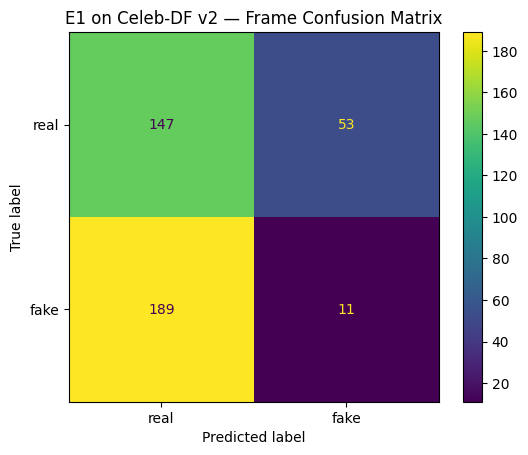

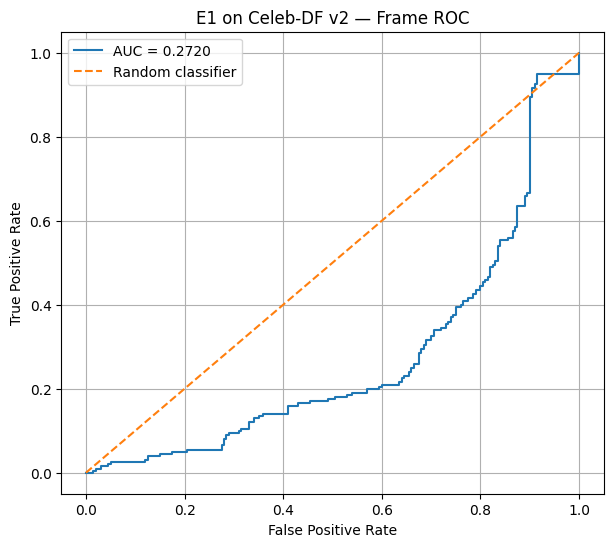

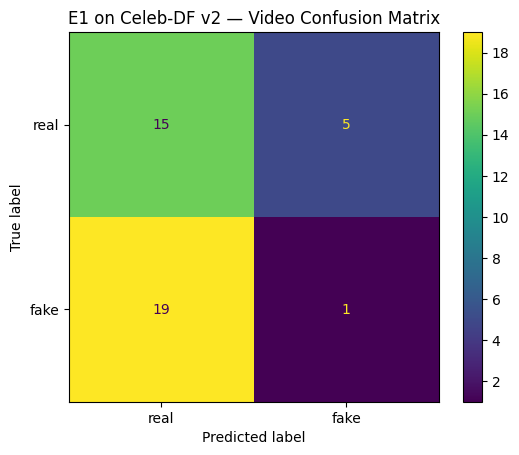

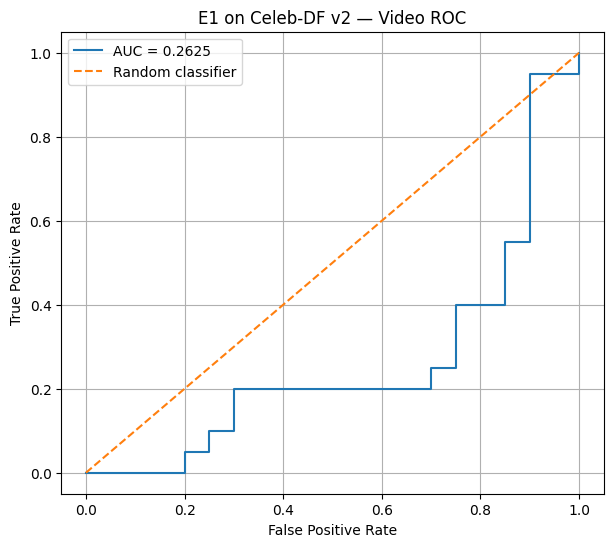

Results saved to: /content/drive/MyDrive/deepfake_project/results/cross_dataset/e1_celebdf_results.json


In [7]:
if RUN_EVALUATION:
    records=[]
    with torch.no_grad():
        for images,labels,class_names,video_ids,filenames,paths in loader:
            probabilities=torch.softmax(model(images.to(DEVICE)),dim=1)[:,MODEL_FAKE_INDEX].cpu().numpy()
            for i,p in enumerate(probabilities):
                predicted=int(p>=DECISION_THRESHOLD); true=int(labels[i])
                records.append({"image_path":paths[i],"filename":filenames[i],"video_id":video_ids[i],"class_name":class_names[i],
                    "true_fake_label":true,"true_class":LABEL_TO_CLASS[true],"predicted_fake_label":predicted,
                    "predicted_class":LABEL_TO_CLASS[predicted],"fake_probability":float(p)})
    frame_df=pd.DataFrame(records)
    assert len(frame_df)==400
    video_df=(frame_df.groupby(["class_name","video_id"],as_index=False)
        .agg(true_fake_label=("true_fake_label","first"),mean_fake_probability=("fake_probability","mean"),number_of_frames=("filename","count")))
    video_df["predicted_fake_label"]=(video_df["mean_fake_probability"]>=DECISION_THRESHOLD).astype(int)
    video_df["true_class"]=video_df["true_fake_label"].map(LABEL_TO_CLASS)
    video_df["predicted_class"]=video_df["predicted_fake_label"].map(LABEL_TO_CLASS)
    assert len(video_df)==40 and video_df["number_of_frames"].eq(10).all()

    frame_metrics=metric_bundle(frame_df.true_fake_label,frame_df.predicted_fake_label,frame_df.fake_probability)
    video_metrics=metric_bundle(video_df.true_fake_label,video_df.predicted_fake_label,video_df.mean_fake_probability)
    frame_report=classification_report(frame_df.true_fake_label,frame_df.predicted_fake_label,labels=[0,1],target_names=["real","fake"],digits=4,zero_division=0)
    video_report=classification_report(video_df.true_fake_label,video_df.predicted_fake_label,labels=[0,1],target_names=["real","fake"],digits=4,zero_division=0)

    for title,count,metrics,report in [("FRAME-LEVEL",len(frame_df),frame_metrics,frame_report),("VIDEO-LEVEL",len(video_df),video_metrics,video_report)]:
        print("="*65); print(f"E1 — CELEB-DF {title} RESULTS"); print("="*65)
        print("Items evaluated :",count); print(f"Accuracy         : {metrics['accuracy']*100:.2f}%")
        print(f"Macro precision  : {metrics['macro_precision']*100:.2f}%"); print(f"Macro recall     : {metrics['macro_recall']*100:.2f}%")
        print(f"Macro F1-score   : {metrics['macro_f1']*100:.2f}%"); print(f"Fake recall      : {metrics['fake_recall']*100:.2f}%")
        print(f"ROC-AUC          : {metrics['roc_auc']:.4f}"); print(report); print("Confusion matrix [real, fake]:"); print(np.asarray(metrics["confusion_matrix"]))

    frame_df.to_csv(FRAME_CSV,index=False); video_df.to_csv(VIDEO_CSV,index=False)
    save_plots("frame",frame_df.true_fake_label,frame_df.fake_probability,frame_metrics,FRAME_CM,FRAME_ROC)
    save_plots("video",video_df.true_fake_label,video_df.mean_fake_probability,video_metrics,VIDEO_CM,VIDEO_ROC)
    result={"experiment":"E1","training_dataset":"FaceForensics++","external_test_dataset":"Celeb-DF v2 pilot",
        "external_input":"full_frame","evaluation_type":"cross-dataset; no retraining or adaptation","checkpoint":str(CHECKPOINT_PATH),
        "decision_threshold":DECISION_THRESHOLD,"model_fake_output_index":MODEL_FAKE_INDEX,
        "video_aggregation":"mean fake probability across 10 frames","frames_evaluated":len(frame_df),"videos_evaluated":len(video_df),
        "frame_level":frame_metrics,"video_level":video_metrics}
    with RESULTS_JSON.open("w",encoding="utf-8") as handle: json.dump(result,handle,indent=2)
    print("Results saved to:",RESULTS_JSON)
else:
    print("Evaluation skipped because RUN_EVALUATION = False.")


## Methodological safeguards

- The E1 checkpoint remains unchanged and receives no Celeb-DF training or adaptation.
- The external threshold is fixed at 0.5.
- The evaluator uses the exact E1 full-frame preprocessing and fake-output orientation.
- The same fixed 20-real/20-fake manifest supplies 10 frames per video.
- The 400-frame/40-video result is reported as a balanced pilot, not the full Celeb-DF benchmark.
